In [1]:
import sys
print(sys.executable)

/Users/yasmine/venv-metal/bin/python


In [2]:
from zipfile import ZipFile
from pathlib import Path
import random
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
from PIL import Image
from rapidocr import RapidOCR

In [3]:
root = Path("datasets/License-Plate-Data")

train_images_dir = root / "train" / "images"
train_labels_dir = root / "train" / "labels"

test_images_dir = root / "test" / "images"
test_labels_dir = root / "test" / "labels"

yaml_path = root / "data.yaml"

In [4]:
for p in [train_images_dir, train_labels_dir, test_images_dir, test_labels_dir, yaml_path]:
    print(p, "->", p.exists())

datasets/License-Plate-Data/train/images -> True
datasets/License-Plate-Data/train/labels -> True
datasets/License-Plate-Data/test/images -> True
datasets/License-Plate-Data/test/labels -> True
datasets/License-Plate-Data/data.yaml -> True


In [5]:
train_images = sorted(train_images_dir.glob("*.png"))
train_labels = sorted(train_labels_dir.glob("*.txt"))

test_images = sorted(test_images_dir.glob("*.png"))
test_labels = sorted(test_labels_dir.glob("*.txt"))

print("Train images :", len(train_images))
print("Train labels :", len(train_labels))
print("Test images  :", len(test_images))
print("Test labels  :", len(test_labels))

Train images : 346
Train labels : 346
Test images  : 87
Test labels  : 87


In [6]:
train_image_stems = {p.stem for p in train_images}
train_label_stems = {p.stem for p in train_labels}

test_image_stems = {p.stem for p in test_images}
test_label_stems = {p.stem for p in test_labels}

print("Train - images sans label :", len(train_image_stems - train_label_stems))
print("Train - labels sans image :", len(train_label_stems - train_image_stems))

print("Test - images sans label  :", len(test_image_stems - test_label_stems))
print("Test - labels sans image  :", len(test_label_stems - test_image_stems))

Train - images sans label : 0
Train - labels sans image : 0
Test - images sans label  : 0
Test - labels sans image  : 0


In [7]:
for img_path in train_images[:5]:
    label_path = train_labels_dir / f"{img_path.stem}.txt"
    print("Image :", img_path.name)
    print("Label :", label_path.name, "| existe :", label_path.exists())
    print("-" * 30)

Image : Cars0.png
Label : Cars0.txt | existe : True
------------------------------
Image : Cars1.png
Label : Cars1.txt | existe : True
------------------------------
Image : Cars10.png
Label : Cars10.txt | existe : True
------------------------------
Image : Cars100.png
Label : Cars100.txt | existe : True
------------------------------
Image : Cars101.png
Label : Cars101.txt | existe : True
------------------------------


In [8]:
def load_image_rgb(image_path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Impossible de lire l'image : {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

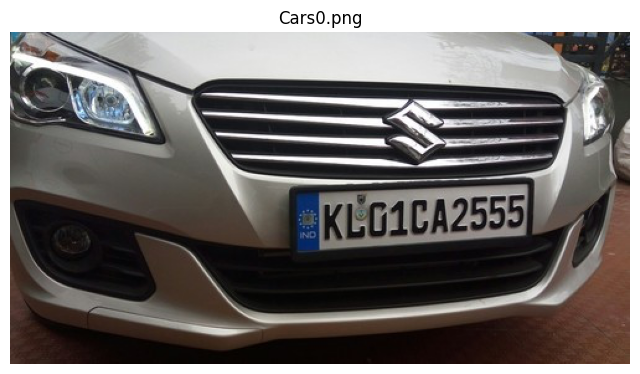

In [9]:
sample_img = train_images[0]
img = load_image_rgb(sample_img)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(sample_img.name)
plt.axis("off")
plt.show()

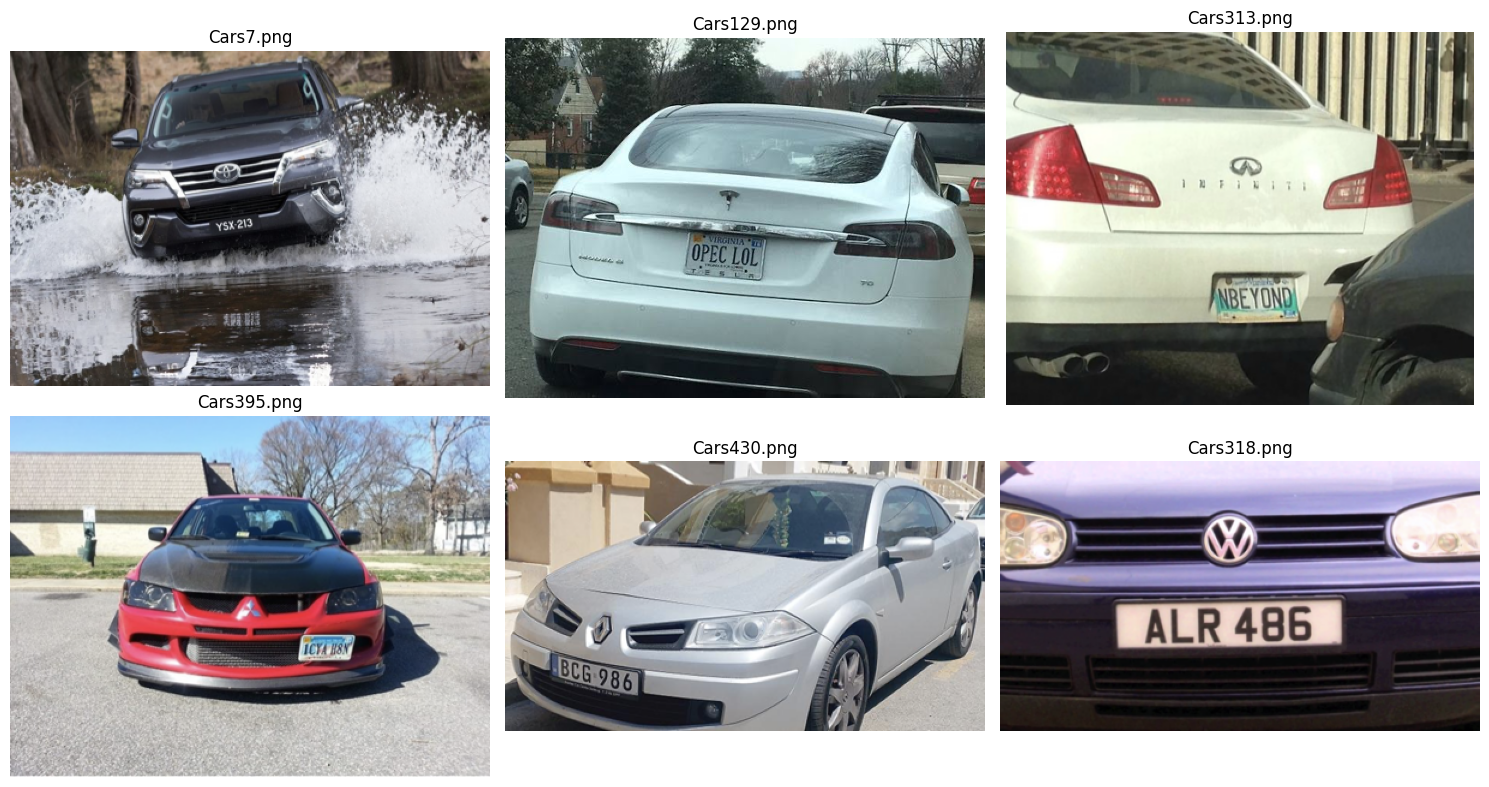

In [11]:
sample_paths = random.sample(train_images, k=min(6, len(train_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_paths):
    img = load_image_rgb(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")

for ax in axes[len(sample_paths):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
def quick_view(img_path):
    img_path = Path(img_path)

    # trouver le label associé
    label_path = img_path.parent.parent / "labels" / (img_path.stem + ".txt")

    print("Image :", img_path)
    print("Label :", label_path)

    # afficher contenu du label
    if label_path.exists():
        with open(label_path, "r") as f:
            print("\nContenu label.txt :")
            print(f.read())
    else:
        print(" pas de label")

    # afficher image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

Image : datasets/License-Plate-Data/train/images/Cars277.png
Label : datasets/License-Plate-Data/train/labels/Cars277.txt

Contenu label.txt :
0 0.15 0.761168384879725 0.06 0.02405498281786944


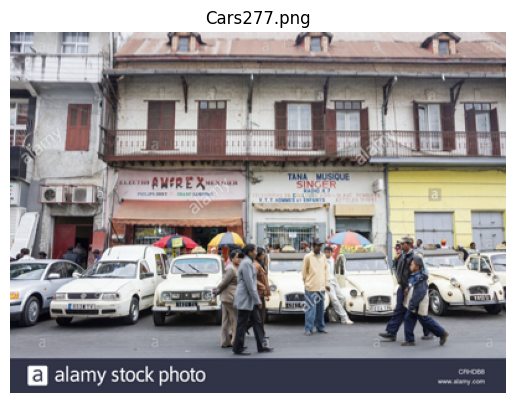

In [13]:
quick_view("datasets/License-Plate-Data/train/images/Cars277.png")

In [14]:
def read_yolo_label(label_path):
    rows = []
    
    with open(label_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            parts = line.split()
            if len(parts) != 5:
                raise ValueError(f"Ligne invalide dans {label_path}: {line}")
            
            class_id, x_center, y_center, width, height = map(float, parts)
            rows.append({
                "class_id": int(class_id),
                "x_center": x_center,
                "y_center": y_center,
                "width": width,
                "height": height
            })
    
    return rows

In [15]:
sample_label = train_labels[0]
label_data = read_yolo_label(sample_label)

print("Fichier :", sample_label.name)
print("Contenu parsé :")
for row in label_data:
    print(row)

Fichier : Cars0.txt
Contenu parsé :
{'class_id': 0, 'x_center': 0.645, 'y_center': 0.5559701492537313, 'width': 0.38599999999999995, 'height': 0.17910447761194032}


In [16]:
with open(sample_label, "r") as f:
    print(f.read())

0 0.645 0.5559701492537313 0.38599999999999995 0.17910447761194032


In [17]:
def yolo_to_xyxy(box, img_width, img_height):
    x_center = box["x_center"] * img_width
    y_center = box["y_center"] * img_height
    width = box["width"] * img_width
    height = box["height"] * img_height

    x_min = x_center - width / 2
    y_min = y_center - height / 2
    x_max = x_center + width / 2
    y_max = y_center + height / 2

    return int(x_min), int(y_min), int(x_max), int(y_max)

In [19]:
def draw_boxes(image, boxes, class_names=None):
    image_copy = image.copy()
    h, w = image_copy.shape[:2]

    for box in boxes:
        x_min, y_min, x_max, y_max = yolo_to_xyxy(box, w, h)

        cv2.rectangle(image_copy, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)

        class_id = box["class_id"]
        label = str(class_id)
        if class_names is not None and class_id < len(class_names):
            label = class_names[class_id]

        cv2.putText(
            image_copy,
            label,
            (x_min, max(20, y_min - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2
        )

    return image_copy

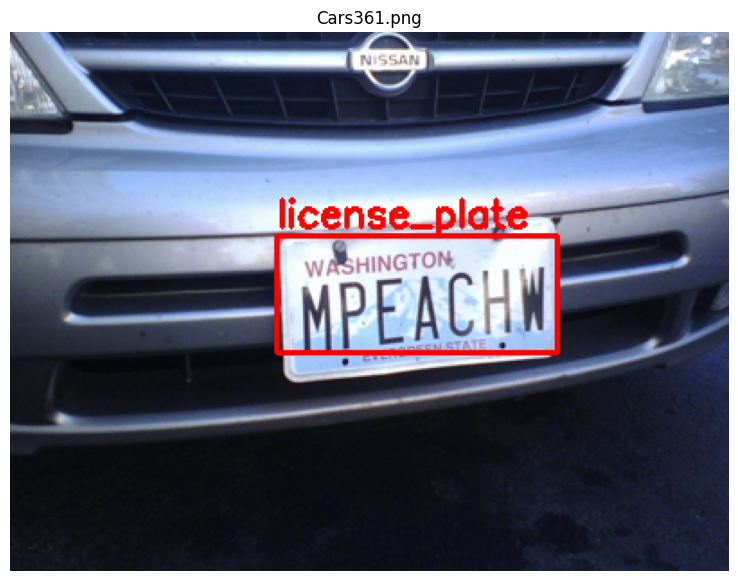

In [22]:
sample_img = train_images[231]
sample_label = train_labels_dir / f"{sample_img.stem}.txt"

img = load_image_rgb(sample_img)
boxes = read_yolo_label(sample_label)
img_boxed = draw_boxes(img, boxes, class_names=["license_plate"])

plt.figure(figsize=(10, 7))
plt.imshow(img_boxed)
plt.title(sample_img.name)
plt.axis("off")
plt.show()

In [23]:

root = Path("datasets/License-Plate-Data").resolve()

new_yaml = f"""
train: {root}/train/images
val: {root}/test/images

nc: 1
names: ['license_plate']
"""

Path("datasets/License-Plate-Data/data.yaml").write_text(new_yaml)

196

In [24]:
yaml_path = Path("datasets/License-Plate-Data/data.yaml")

content = yaml_path.read_text()
print(content)


train: /Users/yasmine/Documents/yolo copy/datasets/License-Plate-Data/train/images
val: /Users/yasmine/Documents/yolo copy/datasets/License-Plate-Data/test/images

nc: 1
names: ['license_plate']



In [25]:
model = YOLO("yolov8n.pt") 

model.train(
    data="datasets/License-Plate-Data/data.yaml",
    epochs=30,
    imgsz=640,
    batch=4,
    device="mps"  #apple silicon GPU hh
)

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.11.0 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/License-Plate-Data/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x12297c790>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048,    

In [26]:
model.model

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

In [27]:
model.val()

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.11.0 CPU (Apple M4 Pro)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 1026.5±430.4 MB/s, size: 653.2 KB)
val: Scanning /Users/yasmine/Documents/yolo copy/datasets/License-Plate-Data/test/labels.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87 45.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.1s/it 6.7s1.7ss
                   all         87         87      0.933      0.851      0.903      0.515
Speed: 0.4ms preprocess, 69.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /Users/yasmine/Documents/yolo copy/runs/detect/val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x3deb2fd50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048,    

In [1]:
model = YOLO("runs/detect/train-3/weights/best.pt")

results = model("datasets/License-Plate-Data/test/images/Cars2.png")
print("done")
print(results[0].boxes)


image 1/1 /Users/yasmine/Documents/yolo/datasets/License-Plate-Data/test/images/Cars2.png: 640x640 1 license_plate, 25.9ms
Speed: 1.4ms preprocess, 25.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
done
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.])
conf: tensor([0.6607])
data: tensor([[229.0487, 173.0109, 269.4536, 193.2000,   0.6607,   0.0000]])
id: None
is_track: False
orig_shape: (400, 400)
shape: torch.Size([1, 6])
xywh: tensor([[249.2511, 183.1055,  40.4048,  20.1891]])
xywhn: tensor([[0.6231, 0.4578, 0.1010, 0.0505]])
xyxy: tensor([[229.0487, 173.0109, 269.4536, 193.2000]])
xyxyn: tensor([[0.5726, 0.4325, 0.6736, 0.4830]])


In [5]:
model.predict(
    "datasets/License-Plate-Data/test/images/Cars12.png",
    show=True
)


image 1/1 /Users/yasmine/Documents/yolo/datasets/License-Plate-Data/test/images/Cars12.png: 256x640 1 license_plate, 29.2ms
Speed: 2.0ms preprocess, 29.2ms inference, 0.4ms postprocess per image at shape (1, 3, 256, 640)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'license_plate'}
 obb: None
 orig_img: array([[[ 36,  52,  64],
         [ 33,  49,  64],
         [ 25,  35,  46],
         ...,
         [  7,   5,   8],
         [ 10,   9,  14],
         [ 15,  10,  19]],
 
        [[ 32,  46,  56],
         [ 38,  53,  66],
         [ 35,  45,  59],
         ...,
         [  4,   4,   7],
         [  9,  10,  15],
         [ 15,  12,  20]],
 
        [[ 33,  43,  52],
         [ 35,  46,  58],
         [ 39,  48,  60],
         ...,
         [  6,   5,   7],
         [  8,  10,  16],
         [ 13,  12,  20]],
 
        ...,
 
        [[  5,   5,   3],
         [ 81,  81,  79],
         [ 93,  93,  92],
         ...,
         [ 34,  51,  60],
         [ 59,  77,  88],
         [ 95, 115, 132]],
 
        [[  4,   4,   3],
         [ 35,  35,  34],
         [ 44,  44,  42],
         ...,
         [ 


image 1/1 /Users/yasmine/Documents/yolo copy/datasets/License-Plate-Data/test/images/Cars157.png: 448x640 1 license_plate, 21.2ms
Speed: 1.2ms preprocess, 21.2ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 640)


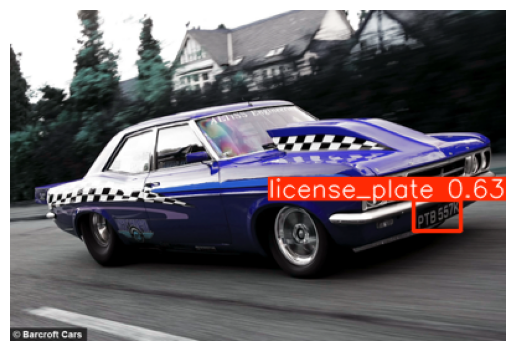

In [46]:
model = YOLO("runs/detect/train-3/weights/best.pt")
results = model("datasets/License-Plate-Data/test/images/Cars157.png")

img = results[0].plot()  # image avec boxes

plt.imshow(img)
plt.axis("off")
plt.show()


image 1/1 /Users/yasmine/Documents/yolo copy/datasets/License-Plate-Data/test/images/Cars135.png: 384x640 1 license_plate, 25.9ms
Speed: 1.7ms preprocess, 25.9ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)


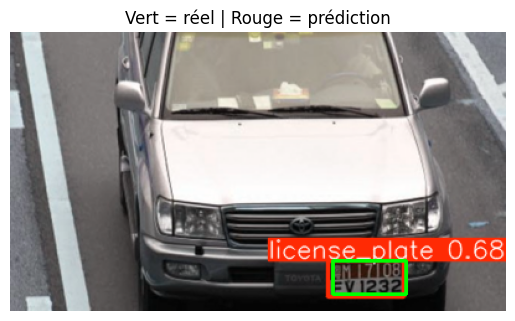

In [29]:
img_path = Path("datasets/License-Plate-Data/test/images/Cars135.png")

img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

results = model(str(img_path))
img_pred = results[0].plot()

label_path = img_path.parent.parent / "labels" / (img_path.stem + ".txt")

with open(label_path) as f:
    for line in f:
        _, x, y, bw, bh = map(float, line.split())

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cv2.rectangle(img_pred, (x1, y1), (x2, y2), (0,255,0), 2)

plt.imshow(img_pred)
plt.title("Vert = réel | Rouge = prédiction")
plt.axis("off")
plt.show()

In [31]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.])
conf: tensor([0.6804])
data: tensor([[256.8080, 184.3159, 317.9983, 213.1411,   0.6804,   0.0000]])
id: None
is_track: False
orig_shape: (225, 400)
shape: torch.Size([1, 6])
xywh: tensor([[287.4031, 198.7285,  61.1903,  28.8252]])
xywhn: tensor([[0.7185, 0.8832, 0.1530, 0.1281]])
xyxy: tensor([[256.8080, 184.3159, 317.9983, 213.1411]])
xyxyn: tensor([[0.6420, 0.8192, 0.7950, 0.9473]])

In [55]:
results[0].boxes.conf

tensor([0.6804])

In [36]:
def extract_plate(img_org, bounding_box, save_path=None, show=True):
    """
    img_org: image PIL déjà ouverte
    bounding_box: (x1, y1, x2, y2)
    save_path: chemin où sauvegarder l'image extraite
    show: afficher ou non dans Jupyter

    return: image PIL cropée
    """
    x1, y1, x2, y2 = map(int, bounding_box)

    # sécuriser les coordonnées
    w, h = img_org.size
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    # crop
    plate = img_org.crop((x1, y1, x2, y2))

    # affichage inline Jupyter
    if show:
        plt.figure(figsize=(4, 2))
        plt.imshow(plate)
        plt.axis("off")
        plt.title("Extracted plate")
        plt.show()

    # sauvegarde
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plate.save(save_path)

    return plate

In [128]:
def extract_text(save_path):
    engine = RapidOCR()
    result = engine(save_path)

    return result

In [171]:
def crop_image(img_path, number): 
    img = Image.open(img_path)
    results = model(img_path)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    if len(boxes) == 0:
        print("No plate detected")
        return None

    save_path = "extracted_plates/Cars" + str(number) + "_plate.png"

    plate = extract_plate(
        img_org=img,
        bounding_box=boxes[0],
        save_path=save_path,
        show=True
    )

    return save_path

In [153]:
def preprocess_plate_for_ocr(img_path,save_path=None,show=True):
    img = Image.open(img_path).convert("L")  # grayscale

    # agrandir
    w, h = img.size
    img = img.resize((w * 3, h * 3))

    # contraste
    img = ImageEnhance.Contrast(img).enhance(2.5)

    # sharpen
    img = img.filter(ImageFilter.SHARPEN)

    # PIL -> numpy
    arr = np.array(img)

    # threshold adaptatif
    arr = cv2.adaptiveThreshold(
        arr,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    out = Image.fromarray(arr)

    if save_path:
        out.save(save_path)
    if show:
        plt.figure(figsize=(8, 3))
        plt.imshow(out, cmap="gray")
        plt.axis("off")
        plt.title("Preprocessed plate")
        plt.show()

    return out

In [172]:
def analyse_image(number):
    img_path = "datasets/License-Plate-Data/test/images/Cars" + str(number) + ".png"
    save_path = "extracted_plates/Cars" + str(number) + "_plate_processed.png"

    # crop image
    extract_path = crop_image(img_path, number)
    print(extract_path)

    if extract_path is None:
        return None

    # process plate for ocr
    preprocess_plate_for_ocr(extract_path, save_path, show=True)

    # extract text with ocr
    result = extract_text(save_path)

    if result is None or result.txts is None:
        print("No text detected")
        return None

    print(result.txts)
    return result.txts


image 1/1 /Users/yasmine/Documents/yolo copy/datasets/License-Plate-Data/test/images/Cars333.png: 448x640 2 license_plates, 36.2ms
Speed: 2.8ms preprocess, 36.2ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)


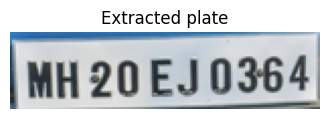

extracted_plates/Cars333_plate.png


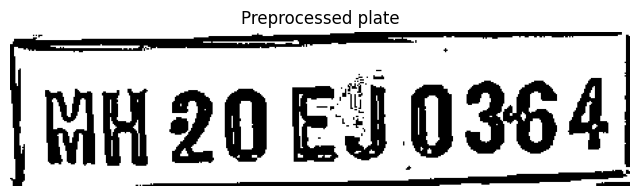

[INFO] 2026-04-23 15:42:17,831 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-23 15:42:17,835 [RapidOCR] download_file.py:60: File exists and is valid: /Users/yasmine/venv-metal/lib/python3.11/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-04-23 15:42:17,836 [RapidOCR] main.py:57: Using /Users/yasmine/venv-metal/lib/python3.11/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-04-23 15:42:17,858 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-23 15:42:17,860 [RapidOCR] download_file.py:60: File exists and is valid: /Users/yasmine/venv-metal/lib/python3.11/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-04-23 15:42:17,860 [RapidOCR] main.py:57: Using /Users/yasmine/venv-metal/lib/python3.11/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-04-23 15:42:17,874 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-23 15:42:17,882 [R

('MH 20 EJ0364',)


('MH 20 EJ0364',)

In [178]:
analyse_image(333)